<a href="https://colab.research.google.com/github/AdamClarkStandke/TransDiffTemp/blob/main/Chapter7_InstructionFineTuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7 and Appendix: Fine-tuning to follow instructions

This notebook implements chapter 7, Appendix D and Appendix E of the book [Build A Large Language Model From Scrath by Sebastian Raschka](https://github.com/rasbt/LLMs-from-scratch). Chapter 7 takes the pretrained weights of gpt2 and fine-tunes it on an instruction set. This is the main step behind developing LLMs for chatbots, personal assistants and AI agents. This process is broken down into three stages:
*   **Stage 1: Preparing the dataset**
*   **Stage 2: Fine-Tuning the Pretrained LLM**
*   **Stage 3: Evaluating the LLM**




# Stage 1: Preparing the Dataset

Preparing the Dataset for fine-tuning a model using PyTorch consists of 1) downloading the dataset and formatting it; 2)  batching the dataset; and 3) creating data loaders. At first I tried using the [LIMA](https://huggingface.co/buckets/DexHeim/lima-bucket) dataset which was created for the paper [LIMA:Less Is More for Alignment](https://arxiv.org/pdf/2305.11206). It consists of 1,000 carefully curated prompts and responses. The paper used a **65 billion** parameter [LLaMa model](https://en.wikipedia.org/wiki/Llama_(language_model)) to finetune on the 1,000 prompts and respons and got amazing results!! (adding evidence to the [Superficial Alignment Hypothesis](https://arxiv.org/pdf/2410.03717) which is still an open question). The largest gpt2 model released was gpt2-xl has over 1 billion parameters and I intially used this model for fine-tuning on the LIMA dataset. However, with only 1,000 examples the model was overfitting after the second epoch!!!

I then turned my attention to the [Stanford Alpaca](https://github.com/tatsu-lab/stanford_alpaca) dataset consisting of 52K instruction based prompts. It consists of an instruction and a response and sometimes an input. After filtering out the prompts with inputs the dataset consisted of 31,323 examples. These were split into 90% training, 5% validation and 5% for later testing/evaluation. This was the dataset I was able to use to fine-tune the gpt2-large model of 774M million parameters for 3 epochs and not overfit!

## Dataset Downloading and Formatting

### Stanford Alpaca

In [1]:
# Helper function to download and load the Alpaca dataset
import json
import os
import requests
def download_and_load_file(file_path, url):
  if not os.path.exists(file_path):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text_data = response.text
    with open(file_path, "w", encoding="utf-8") as file:
      file.write(text_data)
  with open(file_path, "r", encoding="utf-8") as file:
    data = json.load(file)
  return data

In [2]:
# file path to dump json file
file_path = "alpaca_data.json"
# url of github repo containing Alpaca data
url = (
    "https://raw.githubusercontent.com/tatsu-lab/stanford_alpaca/refs/heads/main/alpaca_data.json"
)
# calling above function to download and load data
data_one = download_and_load_file(file_path, url)
# printing number of examples
print("Number of entries:", len(data_one))

Number of entries: 52002


In [3]:
#Function to filer out prompts that contain an input
#so data only contains instructions and responses
def filter_alpacha(data_one):
  s = []
  for i in data_one:
    if i['input'] =='':
      s.append(i)
  return s
fil_data = filter_alpacha(data_one)

In [4]:
#Printing out filtered dataset
len(fil_data)

31323

In [5]:
# Printing out example format of Alpaca data
fil_data[0]

{'instruction': 'Give three tips for staying healthy.',
 'input': '',
 'output': '1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. \n2. Exercise regularly to keep your body active and strong. \n3. Get enough sleep and maintain a consistent sleep schedule.'}

In [6]:
#Printing out instruction and response found in str format
print(f"Instruction: {fil_data[0]['instruction']}")
print(f"Output: {fil_data[0]['output']}")

Instruction: Give three tips for staying healthy.
Output: 1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. 
2. Exercise regularly to keep your body active and strong. 
3. Get enough sleep and maintain a consistent sleep schedule.


In [7]:
# Spliting data into training, testing and validation
train_portion = int(len(fil_data) * 0.90)
test_portion = int(len(fil_data) * 0.05)
val_portion = len(fil_data) - train_portion - test_portion

train_data_al = fil_data[:train_portion]
test_data_al = fil_data[train_portion:train_portion + test_portion]
val_data_al = fil_data[train_portion+test_portion:]

### LIMA

In [8]:
# !pip install jsonlines

In [9]:
# Download this bucket to a local folder if it does not exist
# !hf sync hf://buckets/DexHeim/lima-bucket ./local

In [10]:
# Downloading dataset of LIMA instructions
# import jsonlines
# import json
# file_path = "local/train.jsonl"

# def download_loadfile(file):
#   data = []
#   with open(file, 'r') as f:
#     for line in f:
#         data.append(json.loads(line.strip()))
#   return data

# data_two = download_loadfile(file_path)

In [11]:
# len(data_two)

In [12]:
# data_two[0]

In [13]:
# # sample of instuctions in dataset
# print(f"Instruction: {data_two[0]['conversations'][0]}")
# print(f"Output: {data_two[0]['conversations'][1]}")

In [14]:
# partitioning the dataset
# train_portion = int(len(data_two) * 0.95)
# test_portion = int(len(data_two) * 0.0)
# val_portion = len(data_two) - train_portion - test_portion

# train_data = data_two[:train_portion]
# test_data = data_two[train_portion:train_portion + test_portion]
# val_data = data_two[train_portion+test_portion:]

### Alpaca Prompt Style

Below are two functions to format the instruction datasets into prompt templates for fine-tuning i.e., from JSON dictionary format into prompts. I decided to go with the Alpaca prompt style rather than Microsoft's Phi-3 prompt style since I am using the Alpaca dataset. The Alpaca style uses a structured format with defined sections for instruction, input and response while the Phi-3 style has a simpler format with designated **<|user|>** and **<|assistant|> **tokens.



In [15]:
#Prompt format for LIMA dataset
def format_input(entry):
  instruction_text = (
      f"Below is an instruction that describes a task."
      f"Write a response that appropriately completes the request."
      f"\n\n### Instruction:\n{entry['conversations'][0]}"
  )
  return instruction_text

#Prompt format for Alpaca dataset
def format_input_alpaca(entry):
  instruction_text = (
      f"Below is an instruction that describes a task."
      f"Write a response that appropriately completes the request."
      f"\n\n### Instruction:\n{entry['instruction']}"
  )
  return instruction_text

## Batching the Dataset

Unlike the batching done for classifer fine-tuning (as done in chapter 6) a custom collate function is needed and implemented for instruction fine-tuning. Generally, a collate function is responsible for taking a list of data samples and merging them into a batch for training. For instruction fine-tuning a custom collate function is needed to handle the specific formating requirements for instruction fine-tuning; namely the steps of:  
1.   Formating JSON data into Alpaca prompt style/template
2.   Tokenizing the formatted data
3.   Adding end-of-text tokens (50256) to pad data samples to the same length
4.   Creating a list of target token IDs for the model to learn
5.   Replacing certain padding tokens in the target token IDs with -100

The first two steps are done by implementing an ```InstructionDataset ``` class which formats the input using the functions above and tokenizies the formatted data.

Steps 3, 4, and 5 are handeled by the custom collate function. The custom collate function first **pads the training examples in each batch to the same length while allowing different batches to have different lengths**. Next the custom collate function creates the target token IDs that we want the model to learn during fine-tuning.The target token IDs match the input token IDs **but are shifted one position to the right** which allows the LLM to learn how to predict the next token in a given sequence. And lastly, the padding tokens of 50256, except for the first instance, are replaced with -100 in the target token IDs. By doing so, it allows us to exclude padding tokens from contributing to the training loss calculation, ensuring that only meaningful data influences model learning.





In [16]:
'''
InstructionDataset Class that encaptulates steps 1 and 2
'''
import torch
from torch.utils.data import Dataset, DataLoader
import tiktoken

#Getting tokenizer use by GPT-2
tokenizer = tiktoken.get_encoding("gpt2")

class InstructionDataset(Dataset):
  def __init__(self, data, data_al, tokenizer):
    super().__init__()
    self.data = data
    self.data_al = data_al
    self.encoded_texts = []
    # Note: This portion commented out relates to the LIMA dataset which I first
    # combined with the Alpaca dataset; I decided it was not necessary for
    # fine-tuning
    # for entry in data:
    #   instruction = format_input(entry)
    #   response_text = f"\n\n### Response:\n{entry['conversations'][1]}"
    #   full_text = instruction + response_text
    #   self.encoded_texts.append(tokenizer.encode(full_text))
    # Portion implementing steps 1 and 2
    for entry in data_al:
      instruction = format_input_alpaca(entry) #Alpaca prompt formatting
      response_text = f"\n\n### Response:\n{entry['output']}"
      full_text = instruction + response_text #combines instruction and response
      self.encoded_texts.append(tokenizer.encode(full_text)) #tokenizes prompt

  def __getitem__(self, index):
    return self.encoded_texts[index]

  def __len__(self):
    # return len(self.data) + len(self.data_al)
    return len(self.data_al)

In [17]:
'''
Custom collate function that encaptulates steps 3, 4, and 5
'''
def custom_collate_fn(batch,
                      pad_token_id = 50256,
                      ignore_index = -100,
                      allowed_max_length = 1024,
                      device="cpu",
                      input_mask = False
                      ):
  batch_max_length = max(len(item)+1 for item in batch) #determing longest sequence in the batch
  inputs_ls, targets_ls = [], []
  #padding the input and target sequence for each batch by the longest sequence
  for item in batch:
    new_item = item.copy()
    new_item += [pad_token_id]
    padded = (new_item+[pad_token_id]*(batch_max_length - len(new_item))) #padding the sequence
    inputs = torch.tensor(padded[:-1]) #input sequence
    targets = torch.tensor(padded[1:]) #target sequence

    #converting target padded token IDs into -100 (except for first padded token ID)
    mask = targets == pad_token_id
    indices = torch.nonzero(mask).squeeze()
    if indices.numel() > 1:
      targets[indices[1:]] = ignore_index

    #making sure input and target sequences do not exceed GPT-2's context length
    if allowed_max_length is not None:
      inputs = inputs[:allowed_max_length]
      targets = targets[:allowed_max_length]

    inputs_ls.append(inputs)
    targets_ls.append(targets)

  inputs_tensor = torch.stack(inputs_ls).to(device)
  targets_tensor = torch.stack(targets_ls).to(device)

  return inputs_tensor, targets_tensor

## Creating Dataloaders

These are the dataloaders that batch the data and call the ```custom_collate_fn``` (as detailed above). The ```train_loader``` and ```val_loader``` are given to the training loop and are used to input the data into the model for training.    

In [18]:
from functools import partial

#determines if underlying hardware contains a cuda based gpu
#if so set device to gpu else cpu
if torch.cuda.is_available():
  device = torch.device("cuda")
else:
  device = torch.device("cpu")

#using partial function to create a new version of the
#customized_collate_fn with device argument prefilled
customized_collate_fn = partial(
    custom_collate_fn,
    device=device
)

In [19]:
#use if u have multiple devices (i.e. gpu cluster)
num_workers = 0
#Batch Size
batch_size = 5
torch.manual_seed(123)

#calling InstructionDataset Class to format training data
train_dataset = InstructionDataset(train_data_al, train_data_al, tokenizer)
#creating train Dataloader
train_loader = DataLoader(
    train_dataset,
    batch_size = batch_size,
    collate_fn = customized_collate_fn,
    shuffle = True,
    drop_last = True,
    num_workers = num_workers
)
#calling InstructionDataset Class to format validation data
val_dataset = InstructionDataset(val_data_al, val_data_al, tokenizer)
#creating validation Dataloader
val_loader = DataLoader(
    val_dataset,
    batch_size = batch_size,
    collate_fn = customized_collate_fn,
    shuffle = False,
    drop_last = False,
    num_workers = num_workers
)
#calling InstructionDataset Class to format testing data
test_dataset = InstructionDataset(test_data_al, test_data_al, tokenizer)
#creating testing Dataloader
test_loader = DataLoader(
    test_dataset,
    batch_size = batch_size,
    collate_fn = customized_collate_fn,
    shuffle = False,
    drop_last = False,
    num_workers = num_workers
)

In [20]:
#prints 10 items from the train_loader containing
#the batched input and targets for the model
print("Train loader:")
count=0
for inputs, targets in train_loader:
  print(inputs.shape, targets.shape)
  count+=1
  if count == 10:
    break

Train loader:
torch.Size([5, 96]) torch.Size([5, 96])
torch.Size([5, 137]) torch.Size([5, 137])
torch.Size([5, 136]) torch.Size([5, 136])
torch.Size([5, 237]) torch.Size([5, 237])
torch.Size([5, 150]) torch.Size([5, 150])
torch.Size([5, 119]) torch.Size([5, 119])
torch.Size([5, 233]) torch.Size([5, 233])
torch.Size([5, 177]) torch.Size([5, 177])
torch.Size([5, 179]) torch.Size([5, 179])
torch.Size([5, 189]) torch.Size([5, 189])


# Stage 2: Finetuning the LLM

After all of the previous data pre-processing steps we are ready now for Fine-tuning the LLM. My stage 2 consists of four basic steps rather than three like in the book because I added [Low Rank Adaptation (LoRA)](https://arxiv.org/pdf/2106.09685) as an additional fine-tuning step; namely
1.   **Loading weights of a pretrained LLM**
2.   **Replacing Linear Layers with LoRA Layers**
3.   **Instruction Fine-tuning the LLM on your dataset**
4.   **Viewing Model training and Validation Loss**




## Loading a Pretrained LLM

I decided to download the pretrained weights of the large GPT-2 model consisting of 774M parameters rather than the medium GPT-2 model of 344M parameters as the book did. I copied the [book's](https://github.com/rasbt/LLMs-from-scratch) repository of hosted GPT-2 weights and stored them in my [bucket](https://huggingface.co/buckets/DexHeim/gpt2-from-scratch-pytorch-bucket) for later use.    

In [1]:
#Importing functions and GPT-2 model architecture from previous chapter
import os
import requests
from huggingface_hub import download_bucket_files
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch07/01_main-chapter-code/previous_chapters.py"
!touch "/content/previous_chapters.py"
file_path = "/content/previous_chapters.py"
response = requests.get(url, timeout=100)
response.raise_for_status()
text_data = response.text
with open(file_path, "w", encoding="utf-8") as file:
  file.write(text_data)

In [2]:
from previous_chapters import GPTModel, generate, token_ids_to_text, text_to_token_ids

In [3]:
BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

# different model configuations of GPT-2
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# choosing our model config to use
model_name = "gpt2-large (774M)"

# updating base config with our model config
BASE_CONFIG.update(model_configs[model_name])

# download pretrained weights
'''
gpt2-small-124M.pth
gpt2-medium-355M.pth
gpt2-large-774M.pth
gpt2-xl-1558M.pth
'''
file_name = "gpt2-large-774M.pth"

download_bucket_files(
    bucket_id = "DexHeim/gpt2-from-scratch-pytorch-bucket",
    files = [(f"{file_name}", f'./{file_name}')]
)


'\ngpt2-small-124M.pth\ngpt2-medium-355M.pth\ngpt2-large-774M.pth\ngpt2-xl-1558M.pth\n'

In [24]:
# loading pretrained weights into our model
from safetensors.torch import load_file
gpt = GPTModel(BASE_CONFIG)
gpt.load_state_dict(torch.load(file_name, weights_only=True))
print(gpt)

GPTModel(
  (tok_emb): Embedding(50257, 1280)
  (pos_emb): Embedding(1024, 1280)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1280, out_features=1280, bias=True)
        (W_key): Linear(in_features=1280, out_features=1280, bias=True)
        (W_value): Linear(in_features=1280, out_features=1280, bias=True)
        (out_proj): Linear(in_features=1280, out_features=1280, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1280, out_features=5120, bias=True)
          (1): GELU()
          (2): Linear(in_features=5120, out_features=1280, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_f

## Appendix E: Parameter-Efficient Fine-Tuning with LoRA

One of the problems I ran into when initially fine-tuning the model was actually getting the model to execute on the GPU. Even when using google colab's version of NVIDIA's [G4 Card](https://cloud.google.com/blog/products/compute/g4-vms-powered-by-nvidia-rtx-6000-blackwell-gpus-are-ga) with 95GB of RAM I was still getting out-of-memory (OOM) errors!! I knew that I had to decrease the number of trainable parameters so I turned to Appendix E of the [book](https://github.com/rasbt/LLMs-from-scratch) detaling its implementation of [Low Rank Adaptation (LoRA)](https://arxiv.org/pdf/2106.09685).

As the book details:

> LoRA is a technique that adapts a pretrained model to better suit a specific, often smaller dataset by **adjusting only a small subset of the model’s weight parameters.** The “low-rank” aspect refers to the mathematical concept of limiting model adjustments to a smaller dimensional subspace of the total weight parameter space. This effectively captures the most influential directions of the weight parameter changes during training.

As the [article](https://arxiv.org/pdf/2106.09685) details in greater complexity, the basic gist of it is approximating the weight update matrix of gradients calculated during backpropogation i.e. $ΔW$ with a low-rank matrix decomposition of  matricies; namely B and A. As the authors of the [article](https://arxiv.org/pdf/2106.09685) detail:

> A neural network contains many dense layers which perform matrix multiplication. The weight matrices in these layers typically have full-rank. When adapting to a specific task, [Aghajanyan et al. (2020)](https://arxiv.org/abs/2012.13255) shows that the pre-trained language models have a low “instrisic dimension” [i.e., low dimensional subspace for reparameterization] and can still learn efficiently despite a random projection to a smaller subspace. Inspired by this, we hypothesize the updates to the weights also have a low “intrinsic rank” during adaptation.

The gradient step (i.e. adjusting the weights of the model) becomes: $W_{t+1}=W_{0}-∇_{AB}L(AB_{t})$ where $ W_{0}∈\mathbb{R}^{d×k}$ represents the frozen orginal pretrained weights of the model and $∇_{AB}$ with matrices $A\in\mathbb{R}^{d×r} B∈\mathbb{R}^{r×k}$ represent the trainable weights.

Instead of the book's implementation of LoRA, I relied on the tutorial [Implementing LoRA from scratch](https://sabrresearch.com/cookbooks/implementing-lora-from-scratch-pytorch) which consists of creating the class  ```LinearWithLoRA```

```LinearWithLoRA```creates the matrices A and B along with the alpha scaling factor and the rank dimension. In this implementation the matrix A is intialized using [kaiming uniform](https://docs.pytorch.org/docs/2.13/nn.init.html) distribution and the matrix B is intialized with zeros. In the forward pass the output of the linear layers (i.e. containing the orginal pretrained weights $W_{0}$) is added with the LoRA matrices i.e. AB. The forward pass becomes modified as follows: $h=W_{0}x+ABx$   

The next implementation step is replacing each linear layer of the model with the ```LinearWithLoRA``` layer. That means replacing the linear layers found in the masked multihead attention and the feed forward layers of the transfomer and linear output layer of the model. Instead of using the book's function to swap the linear layer with the ```LinearWithLoRA``` layer again I relied on the tutorial [Implementing LoRA from scratch](https://sabrresearch.com/cookbooks/implementing-lora-from-scratch-pytorch) since I was having problems with the book's implementation





In [25]:
from previous_chapters import calc_loss_loader, train_model_simple

In [26]:
#freezing non-lora pretrained weights
for param in gpt.parameters():
  param.requires_grad = False
total_params = sum(p.numel() for p in gpt.parameters() if p.requires_grad)
print(f"Total trainable parameters after: {total_params:,}")

Total trainable parameters after: 0


In [27]:
import math

class LinearWithLoRA(torch.nn.Module):
  def __init__(self, base, rank, alpha):
    super().__init__()
    self.base = base
    out_features, in_features = base.weight.shape
    self.A  = torch.nn.Parameter(torch.empty(rank, in_features))
    torch.nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
    self.B = torch.nn.Parameter(torch.zeros(out_features, rank))
    self.scale = alpha/rank

  def forward(self, x):
    return self.base(x) + (x @ self.A.T @ self.B.T)*self.scale

  def delta(self):
    return (self.B @ self.A) * self.scale

In [28]:
def add_lora(module, r=8, alpha=16):
    for name, child in list(module.named_children()):
      if isinstance(child, torch.nn.Linear):
          setattr(module, name, LinearWithLoRA(child, r, alpha))
      else:
          add_lora(child, r, alpha)

add_lora(gpt)

In [29]:
for m in gpt.modules():
  if isinstance(m, LinearWithLoRA):
    m.A.requires_grad_(True)
    m.B.requires_grad_(True)

In [30]:
print(gpt)

GPTModel(
  (tok_emb): Embedding(50257, 1280)
  (pos_emb): Embedding(1024, 1280)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): LinearWithLoRA(
          (base): Linear(in_features=1280, out_features=1280, bias=True)
        )
        (W_key): LinearWithLoRA(
          (base): Linear(in_features=1280, out_features=1280, bias=True)
        )
        (W_value): LinearWithLoRA(
          (base): Linear(in_features=1280, out_features=1280, bias=True)
        )
        (out_proj): LinearWithLoRA(
          (base): Linear(in_features=1280, out_features=1280, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): LinearWithLoRA(
            (base): Linear(in_features=1280, out_features=5120, bias=True)
          )
          (1): GELU()
          (2): LinearWithLoRA(
            (base): Linear(in_fea

In [31]:
total_params = sum(p.numel() for p in gpt.parameters() if p.requires_grad)
print(f"Total trainable LoRA parameters: {total_params:,}")

Total trainable LoRA parameters: 7,047,816


## Appendix D: Training Loop with LR warmup with Cosine decay and Gradient Clipping

In [32]:
from previous_chapters import evaluate_model, generate_and_print_sample, calc_loss_batch
import time
def train_model(model, train_loader, val_loader, optimizer, device,
                n_epochs, eval_freq, eval_iter, start_context, tokenizer,
                warmup_steps, initial_lr=3e-05, min_lr=1e-6):
  train_losses, val_losses, track_tokens_seen, track_lrs = [], [], [], []
  tokens_seen, global_step = 0, -1

  peak_lr = optimizer.param_groups[0]["lr"]
  total_training_steps = len(train_loader) * n_epochs
  lr_increment = (peak_lr-initial_lr)/warmup_steps

  for epoch in range(n_epochs):
    model.train()
    for input_batch, target_batch in train_loader:
      optimizer.zero_grad()
      global_step += 1
      if global_step < warmup_steps:
        lr = initial_lr + global_step * lr_increment
      else:
        progress = ((global_step-warmup_steps)/
                    (total_training_steps - warmup_steps))
        lr = min_lr + (peak_lr - min_lr) * 0.5 * (
           1 + math.cos(math.pi * progress))

      for param_group in optimizer.param_groups:
        param_group['lr'] = lr
      track_lrs.append(lr)
      loss = calc_loss_batch(input_batch, target_batch, model, device)
      loss.backward()

      if global_step >= warmup_steps:
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0
        )

      optimizer.step()
      tokens_seen += input_batch.numel()

      if global_step % eval_freq == 0:
        train_loss, val_loss = evaluate_model(
            model, train_loader, val_loader,
            device, eval_iter
        )
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        print(f"Ep {epoch+1} (Iter {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
        )

    generate_and_print_sample(
        model, tokenizer, device, start_context
    )
  return train_losses, val_losses, track_tokens_seen, track_lrs

In [33]:
if torch.cuda.is_available():
  device = torch.device("cuda")
else:
  device = torch.device("cpu")
gpt.to(device)
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(gpt.parameters(), weight_decay=0.1)
num_epochs = 3
warmup_steps = int(0.2 * (len(train_loader) * num_epochs)) # 20% warmup
train_losses, val_losses, tokens_seen, lrs = train_model(
    gpt, train_loader, val_loader, optimizer, device,
    n_epochs=num_epochs, eval_freq=1000, eval_iter=2,
    start_context=format_input_alpaca(val_data_al[0]), tokenizer=tokenizer,
    warmup_steps=warmup_steps, initial_lr=1e-4, min_lr=1e-5
)

end_time = time.time()
execution_time_min = (end_time - start_time) / 60
print(f"Training completed in {execution_time_min:.2f} minutes.")

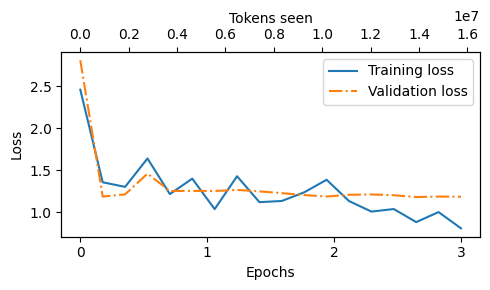

In [34]:
#inspecting model loss
from previous_chapters import plot_losses
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## Merging LoRA Weights and Saving Fine-tuned Model



In [34]:
import torch.nn as nn
class Linear(nn.Linear):
  def __init__(self, in_features, out_features, weight, bias=True):
    # 1. Initialize the parent nn.Linear class
    super().__init__(in_features, out_features, bias=bias)
    # 2. adding intialized weights for the linear layer
    self.weight = weight

  def forward(self, x):
    base_output = super().forward(x)
    return base_output

In [35]:
@torch.no_grad()
def merge():
  for m in gpt.modules():
    if isinstance(m, LinearWithLoRA):
      m.base.weight += m.delta()
      m.B.zero_()
merge()

In [36]:
# most of code snippet taken from https://lightning.ai/lightning-ai/templates/code-lora-from-scratch?section=featured

from functools import partial

# default hyperparameter choices
lora_query = True
lora_key = True
lora_value = True
lora_projection = True
lora_mlp = True
lora_head = True

layers = []

assign_att = partial(Linear, in_features=1280, out_features=1280, bias=True)
assign_ff_one =  partial(Linear, in_features=1280, out_features=5120, bias=True)
assign_ff_two =  partial(Linear, in_features=5120, out_features=1280, bias=True)
assign_out_head = partial(Linear, in_features=1280, out_features=50257, bias=False)

for layer in gpt.trf_blocks:
    if lora_query:
        layer.att.W_query = assign_att(weight=layer.att.W_query.base.weight)
    if lora_key:
        layer.att.W_key = assign_att(weight=layer.att.W_key.base.weight)
    if lora_value:
        layer.att.W_value = assign_att(weight=layer.att.W_value.base.weight)
    if lora_projection:
        layer.att.out_proj = assign_att(weight=layer.att.out_proj.base.weight)
    if lora_mlp:
        layer.ff.layers[0] = assign_ff_one(weight=layer.ff.layers[0].base.weight)
        layer.ff.layers[2] = assign_ff_two(weight=layer.ff.layers[2].base.weight)
if lora_head:
  gpt.out_head = assign_out_head(weight=gpt.out_head.base.weight)

In [37]:
print(gpt)

GPTModel(
  (tok_emb): Embedding(50257, 1280)
  (pos_emb): Embedding(1024, 1280)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1280, out_features=1280, bias=True)
        (W_key): Linear(in_features=1280, out_features=1280, bias=True)
        (W_value): Linear(in_features=1280, out_features=1280, bias=True)
        (out_proj): Linear(in_features=1280, out_features=1280, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1280, out_features=5120, bias=True)
          (1): GELU()
          (2): Linear(in_features=5120, out_features=1280, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_f

In [7]:
torch.save(gpt.state_dict(), "/content/drive/MyDrive/GPT-2/GPT-2-755M-LoRA-Alpaca-weights.pth")

In [12]:
# Upload a local folder to this bucket
!hf auth login
!hf sync /content/drive/MyDrive/GPT-2/ hf://buckets/DexHeim/gpt2-large-774M-ALPACA-sft

? How would you like to log in?  [Use arrows, Enter to confirm]
> Log in with your browser
  Paste an access token
? How would you like to log in? Log in with your browser

    Open this URL in your browser:
        https://hf.co/oauth/device

    And enter the code: 5GFV-723N

    Waiting for authorization........
Token is valid.
The token `oauth-DexHeim` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `oauth-DexHeim`
Note: This token will be refreshed automatically when it expires.
Scanning local directory (1 files)
Scanning remote bucket (1 files)
Comparing files (2 paths)
Sync plan: /content/drive/MyDrive/GPT-2/ -> hf://buckets/DexHeim/gpt2-large-774M-ALPACA-sft
  Uploads: 1
  Downloads: 0
  Deletes: 0
  Skips: 0
Syncing...
Uploading 1 files
Processing Files (0 / 0)      : |          |  0.00B /  0.00B            
New Data Upload               : |          |  0.00B /  

# Stage 3: Evaluating the LLM

In [ ]:
# from huggingface_hub import download_bucket_files
# import torch
# from safetensors.torch import load_file
# BASE_CONFIG = {
#     "vocab_size": 50257,     # Vocabulary size
#     "context_length": 1024,  # Context length
#     "drop_rate": 0.0,        # Dropout rate
#     "qkv_bias": True         # Query-key-value bias
# }

# # different model configuations of GPT-2
# model_configs = {
#     "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
#     "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
#     "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
#     "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
# }

# # choosing our model config to use
# model_name = "gpt2-large (774M)"

# # updating base config with our model config
# BASE_CONFIG.update(model_configs[model_name])

# # download fine-tuned weights
# file_name = "GPT-2-755M-LoRA-Alpaca-weights.pth"

# download_bucket_files(
#     bucket_id = "DexHeim/gpt2-large-774M-ALPACA-sft",
#     files = [(f"{file_name}", f'./{file_name}')]
# )

# gpt = GPTModel(BASE_CONFIG)
# gpt.load_state_dict(torch.load(file_name, weights_only=True))